In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('pizza_sales_cleaned.csv')

In [3]:
df.head()

,pizza_id,order_id,order_date,order_time,day_of_week,is_weekend,month_name,quarter,time_of_day,pizza_name_id,pizza_name,pizza_category,pizza_size,pizza_ingredients,is_vegetarian,quantity,order_size,unit_price,total_price,revenue_category
0,1,1,2015-01-01,11:38:36,Thursday,Weekday,Jan,Q1,Morning,hawaiian_m,The Hawaiian Pizza,Classic,M,"Sliced Ham, Pineapple, Mozzarella Cheese",Non-Veg,1,Small,13.25,13.25,Standard
1,2,2,2015-01-01,11:57:40,Thursday,Weekday,Jan,Q1,Morning,classic_dlx_m,The Classic Deluxe Pizza,Classic,M,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",Non-Veg,1,Small,16.00,16.00,Standard
2,3,2,2015-01-01,11:57:40,Thursday,Weekday,Jan,Q1,Morning,five_cheese_l,The Five Cheese Pizza,Veggie,L,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",Veg,1,Small,18.50,18.50,Standard
3,4,2,2015-01-01,11:57:40,Thursday,Weekday,Jan,Q1,Morning,ital_supr_l,The Italian Supreme Pizza,Supreme,L,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",Non-Veg,1,Small,20.75,20.75,Premium
4,5,2,2015-01-01,11:57:40,Thursday,Weekday,Jan,Q1,Morning,mexicana_m,The Mexicana Pizza,Veggie,M,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",Veg,1,Small,16.00,16.00,Standard


In [4]:
df.describe()

,pizza_id,order_id,quantity,unit_price,total_price
count,48620.000000,48620.000000,48620.000000,48620.000000,48620.000000
mean,24310.500000,10701.479761,1.019622,16.494132,16.821474
std,14035.529381,6180.119770,0.143077,3.621789,4.437398
min,1.000000,1.000000,1.000000,9.750000,9.750000
25%,12155.750000,5337.000000,1.000000,12.750000,12.750000
50%,24310.500000,10682.500000,1.000000,16.500000,16.500000
75%,36465.250000,16100.000000,1.000000,20.250000,20.500000
max,48620.000000,21350.000000,4.000000,35.950000,83.000000


In [5]:
df.columns

Index(['pizza_id', 'order_id', 'order_date', 'order_time', 'day_of_week',
       'is_weekend', 'month_name', 'quarter', 'time_of_day', 'pizza_name_id',
       'pizza_name', 'pizza_category', 'pizza_size', 'pizza_ingredients',
       'is_vegetarian', 'quantity', 'order_size', 'unit_price', 'total_price',
       'revenue_category'],
      dtype='str')

### 1: Univariate Analysis

#### Q1: What is the distribution of `total_price`?

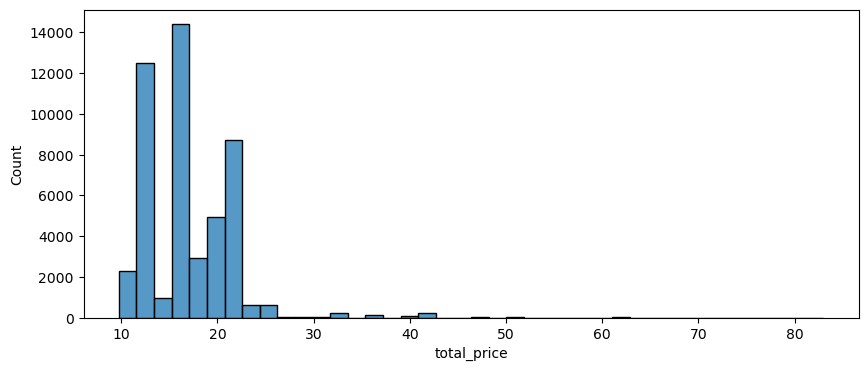

In [6]:
plt.figure(figsize = (10,4))
sns.histplot(df, x = 'total_price', bins = 40)
plt.show()

In [7]:
df[df['total_price'] > 60]

,pizza_id,order_id,order_date,order_time,day_of_week,is_weekend,month_name,quarter,time_of_day,pizza_name_id,pizza_name,pizza_category,pizza_size,pizza_ingredients,is_vegetarian,quantity,order_size,unit_price,total_price,revenue_category
183,184,78,2015-01-02,12:28:14,Friday,Weekday,Jan,Q1,Lunch,spicy_ital_l,The Spicy Italian Pizza,Supreme,L,"Capocollo, Tomatoes, Goat Cheese, Artichokes, ...",Veg,3,Large,20.75,62.25,Premium
18317,18318,8040,2015-05-15,14:13:27,Friday,Weekday,May,Q2,Lunch,thai_ckn_l,The Thai Chicken Pizza,Chicken,L,"Chicken, Pineapple, Tomatoes, Red Peppers, Tha...",Non-Veg,3,Large,20.75,62.25,Premium
35496,35497,15674,2015-09-19,14:16:35,Saturday,Weekend,Sep,Q3,Lunch,cali_ckn_l,The California Chicken Pizza,Chicken,L,"Chicken, Artichoke, Spinach, Garlic, Jalapeno ...",Non-Veg,4,Large,20.75,83.00,Premium
35627,35628,15728,2015-09-20,12:30:44,Sunday,Weekend,Sep,Q3,Lunch,ital_cpcllo_l,The Italian Capocollo Pizza,Classic,L,"Capocollo, Red Peppers, Tomatoes, Goat Cheese,...",Veg,3,Large,20.50,61.50,Premium
37638,37639,16619,2015-10-08,12:19:53,Thursday,Weekday,Oct,Q4,Lunch,prsc_argla_l,The Prosciutto And Arugula Pizza,Supreme,L,"Prosciutto Di San Daniele, Arugula, Mozzarella...",Veg,3,Large,20.75,62.25,Premium
38819,38820,17112,2015-10-17,12:56:31,Saturday,Weekend,Oct,Q4,Lunch,bbq_ckn_l,The Barbecue Chicken Pizza,Chicken,L,"Barbecued Chicken, Red Peppers, Green Peppers,...",Non-Veg,3,Large,20.75,62.25,Premium


#### `Insight`
- Distribution is `right-skeewed` - most of the orders between `$10 - $25`.
- Peak range `$15 - $17` - most common price point.
- Very less orders exist in `$30+` range.
- Outliers exist in range `$50 - $85` - multiple quantity orders.

#### Q2: What is the distribution of `quantity`?

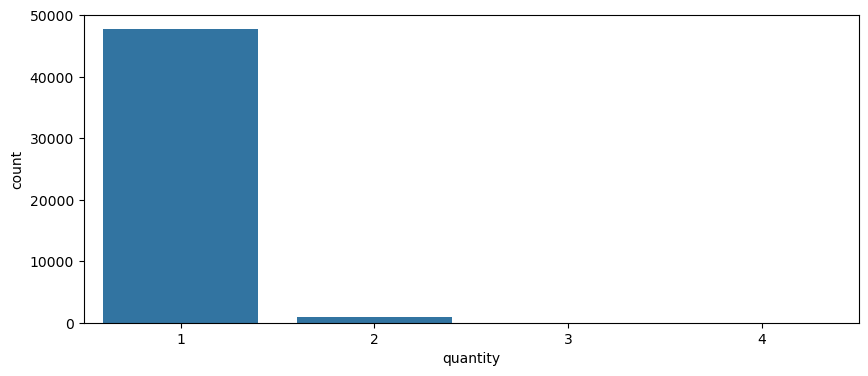

In [8]:
plt.figure(figsize = (10,4))
sns.countplot(df, x = 'quantity')
plt.show()

In [9]:
df['quantity'].value_counts().reset_index()

,quantity,count
0,1,47693
1,2,903
2,3,21
3,4,3


#### `Insight`
- `47,693` orders are for single pizza - most of the customers order just 1 pizza.
- 2, 3, 4 quantity very rare.
- Data heavily imbalanced - 1 quantity overwhelmingly dominant.

#### Q3: What is the distribution of `unit_price`?

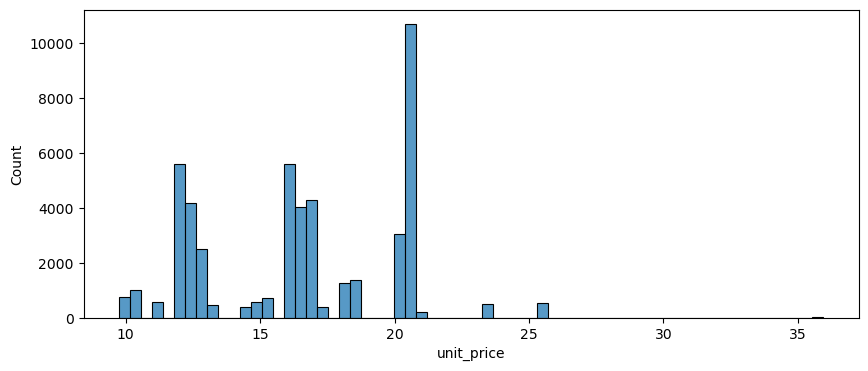

In [10]:
plt.figure(figsize = (10,4))
sns.histplot(df, x = 'unit_price')
plt.show()

In [11]:
df['unit_price'].value_counts()

unit_price
20.75    8685
12.00    5600
16.00    4474
16.75    4294
16.50    4040
12.50    3328
20.25    3032
12.75    2507
20.50    1998
18.50    1359
17.95    1273
16.25    1114
10.50    1001
12.25     830
9.75      739
15.25     712
14.75     577
11.00     570
25.50     544
23.65     480
13.25     473
14.50     391
17.50     381
21.00     190
35.95      28
Name: count, dtype: int64

#### `Insight`
- `$20.75` is the most common price - `8,685` orders
- `$12.00` second most common price - `5600` orders
- `$35.95` is least common price - only 28 orders
- Can divide into 3 cluster
  - Budget Cluster: `$9.75 - $14.75`
  - Standard Cluster: `$15.25 - $18.50`
  - Premium Cluster: `$20.25 - $35.95`

#### Q4: What is the value count of `pizza_category`? 

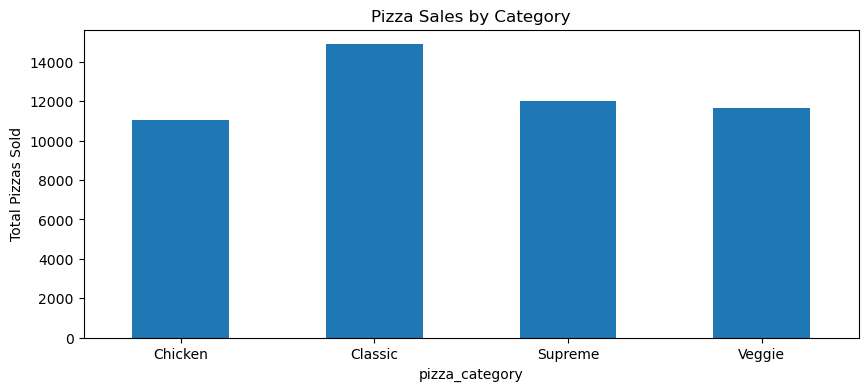

In [12]:

df.groupby('pizza_category')['quantity'].sum().plot(kind = 'bar', figsize = (10,4))
plt.ylabel('Total Pizzas Sold')
plt.title('Pizza Sales by Category')
plt.xticks(rotation=0)
plt.show()

In [13]:
df.groupby('pizza_category')['quantity'].sum()

pizza_category
Chicken    11050
Classic    14888
Supreme    11987
Veggie     11649
Name: quantity, dtype: int64

#### `Insight`

- `Classic` category sold highest total pizzas
- `Chicken` sold lowest among categories
- Category distribution relatively balanced
- Difference exists because some orders contain multiple pizzas

#### Q5: What is the value count of `pizza_size`?

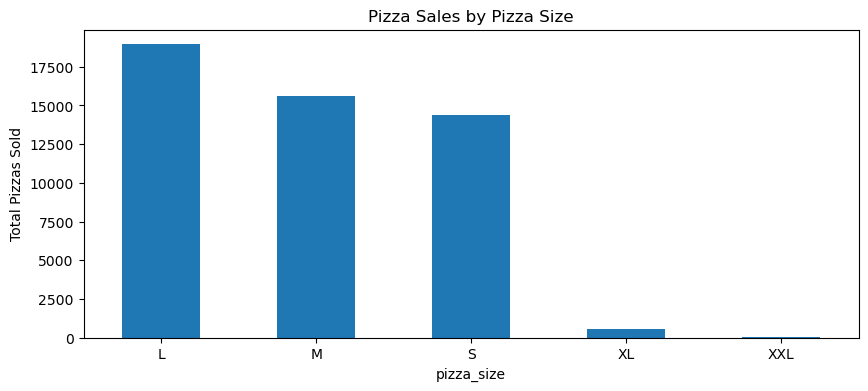

In [14]:

df.groupby('pizza_size')['quantity'].sum().plot(kind = 'bar', figsize = (10,4))
plt.ylabel('Total Pizzas Sold')
plt.title('Pizza Sales by Pizza Size')
plt.xticks(rotation=0)
plt.show()

In [15]:
df.groupby('pizza_size')['quantity'].sum()

pizza_size
L      18956
M      15635
S      14403
XL       552
XXL       28
Name: quantity, dtype: int64

#### `Insight`
- Large(L) most popular - 18,956 
- M & S near to same - balanced demand
- `XL` & `XXL` very low demand - `552` & `28` 
- Clear pattern: `L > M > S >> XL >> XXL`
- `XL + XXL` contribute only `~1.2%` of total pizzas sold

#### Q6: What is the value count of `time_of_day`?

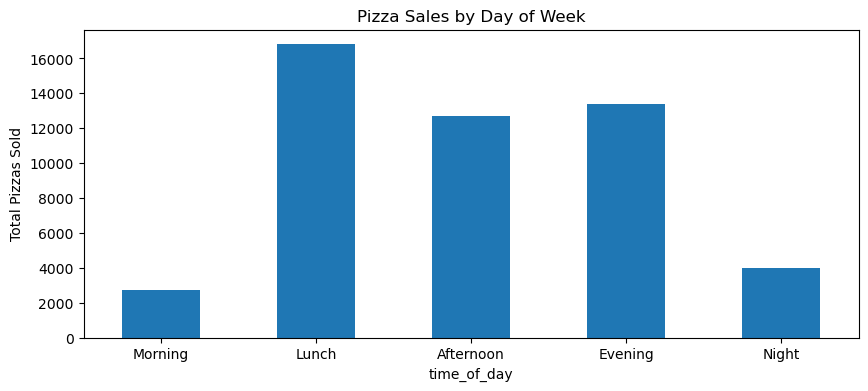

In [16]:
order = ['Morning','Lunch','Afternoon','Evening','Night']
df.groupby('time_of_day')['quantity'].sum().reindex(order).plot(kind = 'bar', figsize = (10,4))
plt.ylabel('Total Pizzas Sold')
plt.title('Pizza Sales by Day of Week')
plt.xticks(rotation=0)
plt.show()

In [17]:
df.groupby('time_of_day')['quantity'].sum()

time_of_day
Afternoon    12666
Evening      13357
Lunch        16802
Morning       2750
Night         3999
Name: quantity, dtype: int64

#### `Insight`
- `Lunch` is the busiest time - `16,802` pizzas sold
- `Evening` second - 13,357 pizzas sold
- `Afternoon` follows – `12,666` pizzas sold
- `Night` has lower demand – `3,999` pizzas sold
- `Mornign` is the least busiest time - `2,750` (fewer people eat pizza between `9 - 11AM`) 
- `Peak time`: `Lunch` + `Evening`
- These two periods contribute the majority of sales
- `Morning` demand is very low (early hours, low traffic)

#### Q7: What is the value count of `day_of_week`?

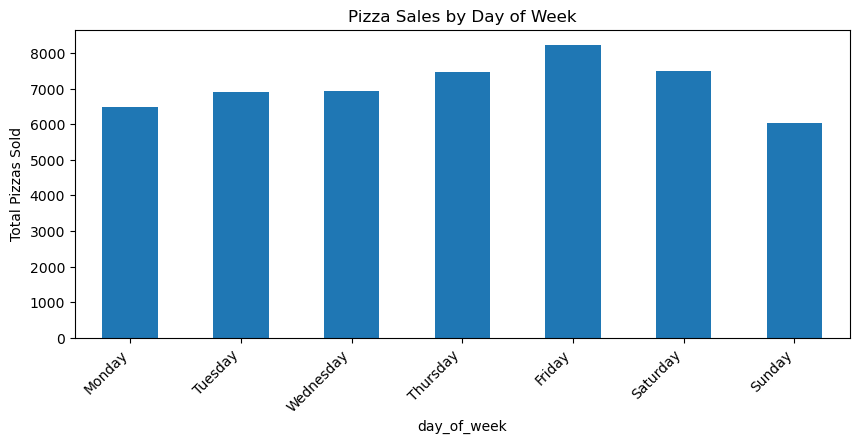

In [18]:
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
df.groupby('day_of_week')['quantity'].sum().reindex(order).plot(kind = 'bar', figsize = (10,4))
plt.ylabel('Total Pizzas Sold')
plt.title('Pizza Sales by Day of Week')
plt.xticks(rotation=45, ha = 'right')
plt.show()

In [19]:
df.groupby('day_of_week')['quantity'].sum()

day_of_week
Friday       8242
Monday       6485
Saturday     7493
Sunday       6035
Thursday     7478
Tuesday      6895
Wednesday    6946
Name: quantity, dtype: int64

#### `Insight`
- Friday records the highest pizza sales(8242 units)
- Sunday shows the lowest demand (6035)
- Weekdays remain relatively stable with no extreame variation
- Slightly higher demand observed towards the end of the week.

#### Q8: What is the distribution of `is_weekend`?

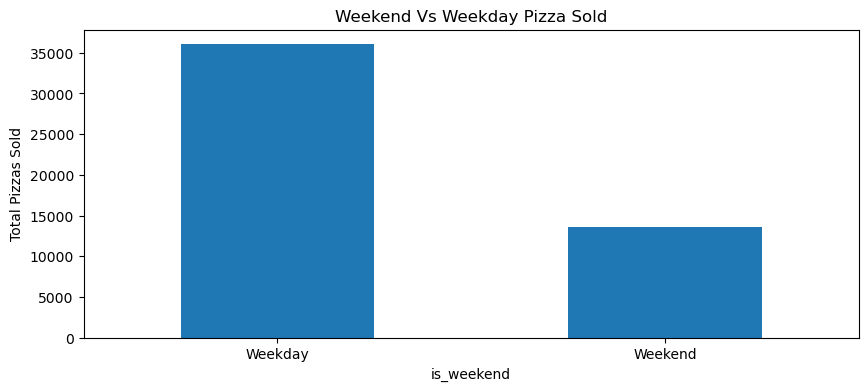

In [20]:
df.groupby('is_weekend')['quantity'].sum().plot(kind = 'bar', figsize = (10,4))
plt.ylabel('Total Pizzas Sold')
plt.title('Weekend Vs Weekday Pizza Sold')
plt.xticks(rotation=0)
plt.show()

In [21]:
df.groupby('is_weekend')['quantity'].sum()

is_weekend
Weekday    36046
Weekend    13528
Name: quantity, dtype: int64

#### `Insight`

- Most of Pizzas sold in Weekday - 36,046
- In Weekend the number of pizza sold 13528 - near one third of Weekday's sold
- The reason of this Weekday = 5days and Weekend = 2days
- Per day average
    - Weekday: 36,046/5 = ~7209/day
    - Weekend: 13,528/2 = ~6764/day
- not a big difference on per day basis

#### Q9: What is the value count of `is_vegetarian`?

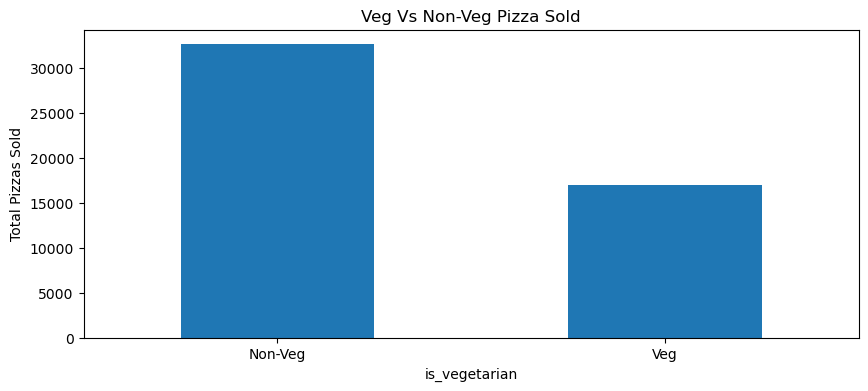

In [22]:
df.groupby('is_vegetarian')['quantity'].sum().plot(kind = 'bar', figsize = (10,4))
plt.ylabel('Total Pizzas Sold')
plt.title('Veg Vs Non-Veg Pizza Sold')
plt.xticks(rotation=0)
plt.show()

In [23]:
df.groupby('is_vegetarian')['quantity'].sum()

is_vegetarian
Non-Veg    32616
Veg        16958
Name: quantity, dtype: int64

#### `Insight`

- Non-Veg most popular - 32616 pizza sold
- Veg only 16958 - nearly half of Non-Veg
- Ratio: Non-Veg 66% vs 34%
- Non-Veg dominant on the menu

#### Q10: What is the value count of `order_size`?

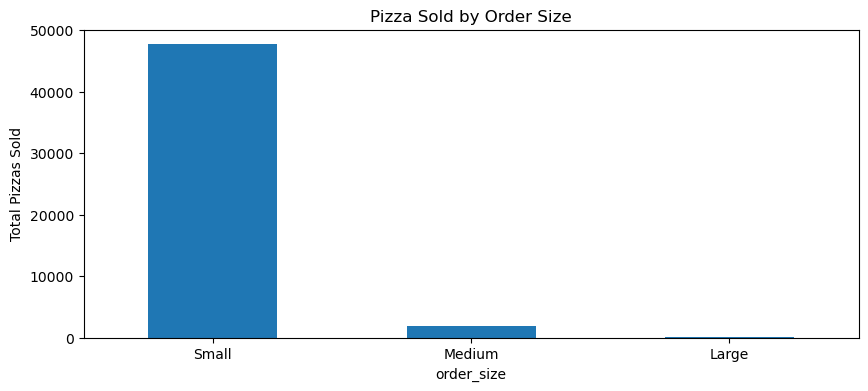

In [24]:
order = ['Small','Medium','Large']
df.groupby('order_size')['quantity'].sum().reindex(order).plot(kind = 'bar',figsize = (10,4))
plt.ylabel('Total Pizzas Sold')
plt.title('Pizza Sold by Order Size')
plt.xticks(rotation=0)
plt.show()

In [25]:
df.groupby('order_size')['quantity'].sum()

order_size
Large        75
Medium     1806
Small     47693
Name: quantity, dtype: int64

#### `Insight`

- Small (qty=1) overwhelmingly dominant — 47,693 orders
- Medium (qty=2) only 1,806
- Large (qty=3+) only 75 — rare
- consistent with the result of Q2 — most of the customer order single pizza

#### Q11: What is the distribution of revenue_category?

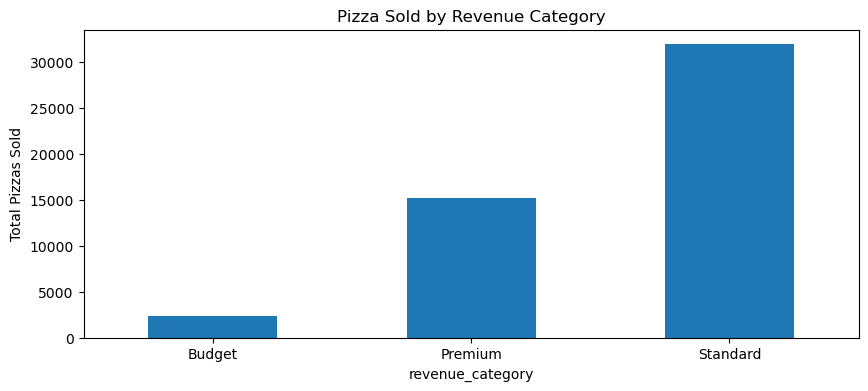

In [26]:
df.groupby('revenue_category')['quantity'].sum().plot(kind = 'bar', figsize = (10,4))
plt.ylabel('Total Pizzas Sold')
plt.title('Pizza Sold by Revenue Category')
plt.xticks(rotation=0)
plt.show()

In [27]:
df.groupby('revenue_category')['quantity'].sum()

revenue_category
Budget       2349
Premium     15270
Standard    31955
Name: quantity, dtype: int64

#### `Insight`
- Standard revenue are the most - 31955 pizzas(`$12-$20` range)
- Premium Second - 15279 pizzas (`$20+` range)
- Dudget are the least - only 2349 pizzas (under `$12` range)
- Customer most of the time spend their money for Standard & Premium range
- Budget range not the that much popular - menu could be reconsider

### Bivariate Analysis

#### Q12: Which pizza category generates the most revenue?


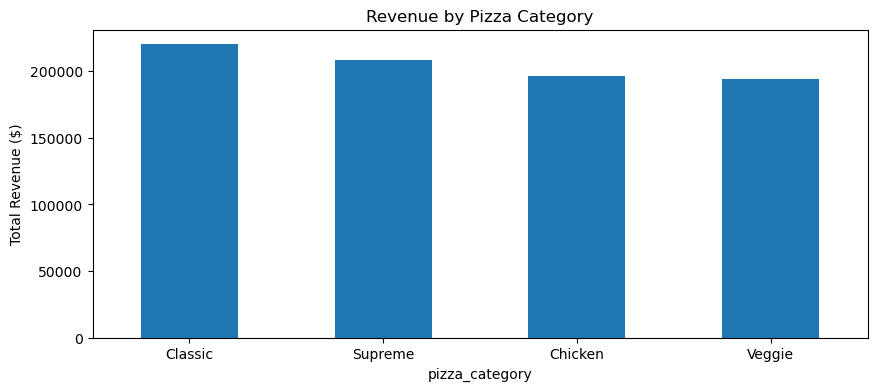

In [28]:
df.groupby('pizza_category')['total_price'].sum().sort_values(ascending = False).plot(kind = 'bar', figsize = (10,4))
plt.ylabel('Total Revenue ($)')
plt.title('Revenue by Pizza Category')
plt.xticks(rotation=0)
plt.show()

In [29]:
df.groupby('pizza_category')['total_price'].sum()

pizza_category
Chicken    195919.50
Classic    220053.10
Supreme    208197.00
Veggie     193690.45
Name: total_price, dtype: float64

#### `Insight`

- Classic generate most of revenue — $220,053
- Supreme second — `$208,197`
- Chicken and Veggie nearly similar — `~$194K – $196K`
- Not a big difference of revenue of all category - balanced revenue distribution
- Classic category top both  quantity and revenue — consistent performer

#### Q13: Which pizza size generates the most revenue?


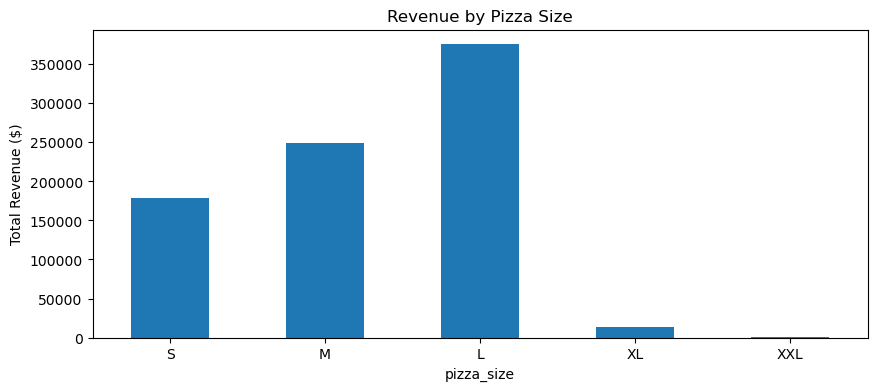

In [30]:
order = ['S','M','L','XL','XXL']
df.groupby('pizza_size')['total_price'].sum().reindex(order).plot(kind = 'bar', figsize = (10,4))
plt.ylabel('Total Revenue ($)')
plt.title('Revenue by Pizza Size')
plt.xticks(rotation=0)
plt.show()

In [31]:
df.groupby('pizza_size')['total_price'].sum()

pizza_size
L      375318.70
M      249382.25
S      178076.50
XL      14076.00
XXL      1006.60
Name: total_price, dtype: float64

### `Insight`
- Large(L) generate the highest revenue - `$375,318` (45.9% of total)
- -Medium is second - `$249,382`
- Small/Regular(S) is third - `$178,076`
- XL and XXL contribute very little - `$14,076` and `$1,006` respectively
- Clear pattern: `L > M > S >> XL >> XXL`
- Large size is the primary revenue driver - should be prioritized in promotions

#### Q14: What is the revenue trend across months?

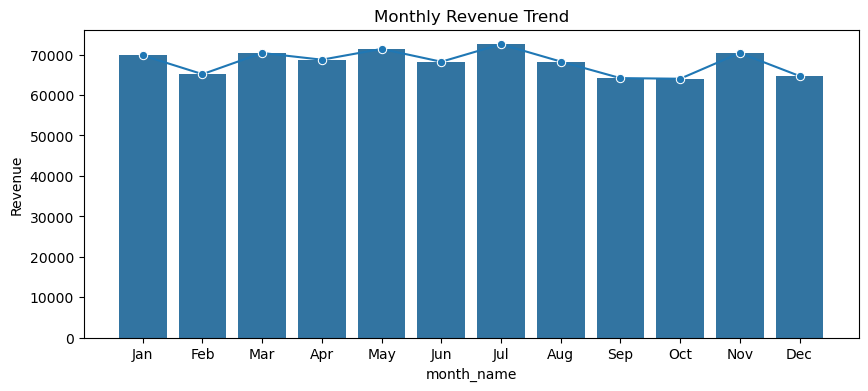

In [32]:
order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly_revenue = (df.groupby('month_name')['total_price'].sum().reindex(order).reset_index())
plt.figure(figsize = (10,4))
sns.barplot(data = monthly_revenue,
            x = 'month_name',
            y= 'total_price')
sns.lineplot(data=monthly_revenue,
             x='month_name',
             y='total_price',
             marker='o')
plt.ylabel('Revenue')
plt.title('Monthly Revenue Trend')
plt.show()

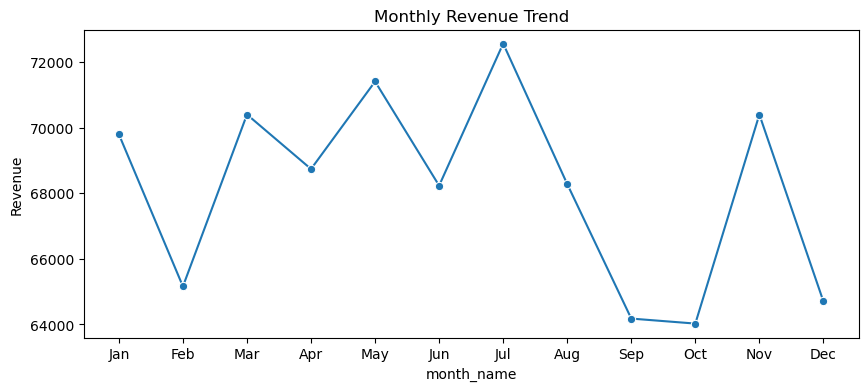

In [33]:
plt.figure(figsize = (10,4))
sns.lineplot(data=monthly_revenue,
             x='month_name',
             y='total_price',
             marker='o')
plt.ylabel('Revenue')
plt.title('Monthly Revenue Trend')
plt.show()

In [34]:
df.groupby('month_name')['total_price'].sum()

month_name
Apr    68736.80
Aug    68278.25
Dec    64701.15
Feb    65159.60
Jan    69793.30
Jul    72557.90
Jun    68230.20
Mar    70397.10
May    71402.75
Nov    70395.35
Oct    64027.60
Sep    64180.05
Name: total_price, dtype: float64

### `Insight`

- `July` generated the `highest` revenue — $72,557
- `May` and `March` are close second — `$71,402` and `$70,397`
- `October` is the lowest — `$64,027`
- `December` and `September` are also relatively `low` — `~$64K`
- Overall monthly revenue is quite consistent — ranging from `$64K` to `$72K`
- No dramatic peaks or drops — stable demand throughout the year
- Slight dip in `Sep`, `Oct`, `Dec` — could be seasonal pattern

#### Q15: What is the revenue trend across quarters?

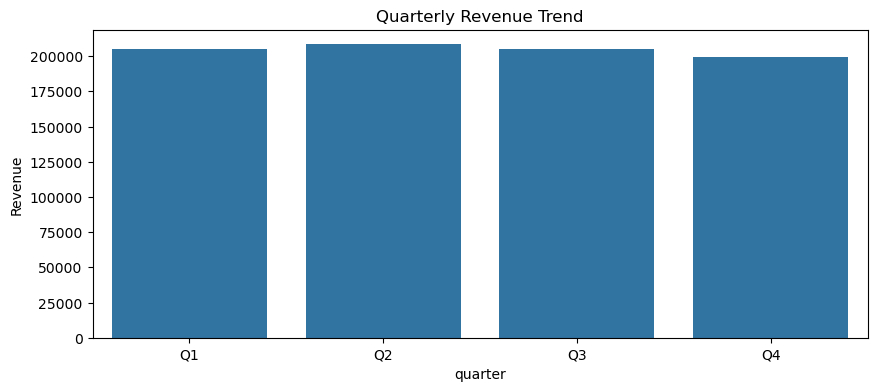

In [35]:
revenue_trend = df.groupby('quarter')['total_price'].sum().reset_index()
plt.figure(figsize=(10,4))
sns.barplot(data = revenue_trend,
           x = 'quarter',
           y = 'total_price') 
plt.ylabel('Revenue')
plt.title('Quarterly Revenue Trend')
plt.show()

In [59]:
df.groupby('quarter')['total_price'].sum()

quarter
Q1    205350.00
Q2    208369.75
Q3    205016.20
Q4    199124.10
Name: total_price, dtype: float64

#### `Insight`

- `Q2` generated the highest revenue — `$208,369`
- `Q1` and `Q3` are very close — `$205,350` and `$205,016`
- `Q4` is the lowest — `$199,124`
- Revenue is very `consistent` across all quarters — difference between highest and lowest is only `~$9,245`
- Slight decline in `Q4` — `Sep`, `Oct`, `Dec` were the weakest months
- Business has stable year-round demand with no major seasonal fluctuations

#### Q16: Which time of day generates the most revenue?

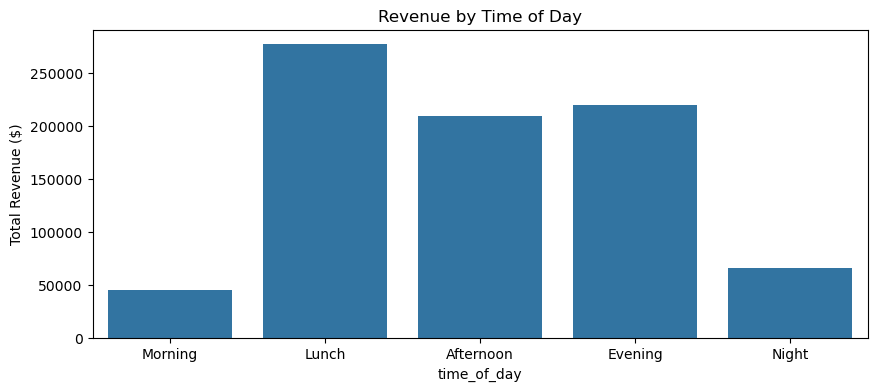

In [37]:
time_order = ['Morning', 'Lunch', 'Afternoon', 'Evening', 'Night']
revenue_shift = df.groupby('time_of_day')['total_price'].sum().reindex(time_order).reset_index()
plt.figure(figsize = (10,4))
sns.barplot(data = revenue_shift,
           x = 'time_of_day',
           y = 'total_price')
plt.ylabel('Total Revenue ($)')
plt.title('Revenue by Time of Day')
plt.show()

In [58]:
df.groupby('time_of_day')['total_price'].sum()

time_of_day
Afternoon    209285.15
Evening      220141.15
Lunch        277145.00
Morning       45322.45
Night         65966.30
Name: total_price, dtype: float64

#### `Insight`

- `Lunch` generates the highest revenue — `$277,145` (`33.8%` of total)
- `Evening` is second — `$220,141`
- `Afternoon` is third — `$209,285`
- `Morning` is the lowest — `$45,322` (only `5.5%` of total)
- `Night` is also low — `$65,966`
- `Lunch + Evening` combined = `~$497K` — over `60%` of total revenue
- Business should `focus staffing` and `promotions` during `Lunch` and `Evening` hours



#### Q17: What is the revenue comparison between Weekday and Weekend?

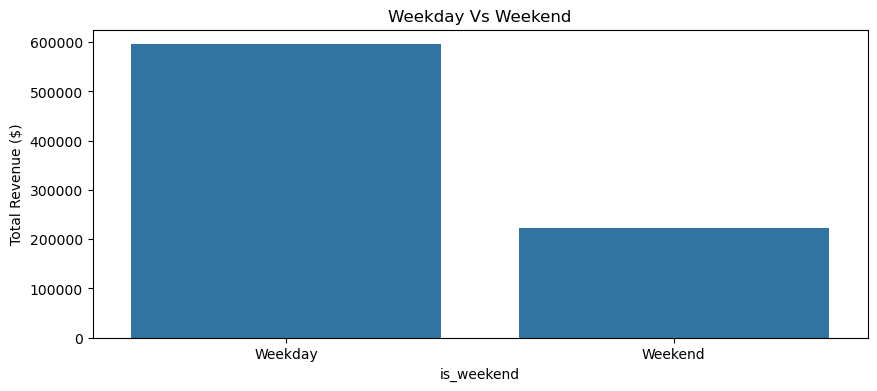

In [39]:
is_weekend = df.groupby('is_weekend')['total_price'].sum().reset_index()
plt.figure(figsize = (10,4))
sns.barplot(data = is_weekend,
           x = 'is_weekend',
           y = 'total_price')
plt.ylabel('Total Revenue ($)')
plt.title('Weekday Vs Weekend')
plt.show()

In [57]:
df.groupby('is_weekend')['total_price'].sum()

is_weekend
Weekday    595474.15
Weekend    222385.90
Name: total_price, dtype: float64

#### `Insight`

- `Weekday` generates significantly more revenue — `$595,474` (`72.8%` of total)
- `Weekend` contributes — `$222,386` (`27.2%` of total)
- But per day average:
    - `Weekday`: `$595,474 ÷ 5` = `$119,095/day`
    - `Weekend`: `$222,386 ÷ 2` = `$111,193/day`
- Per day basis the difference is only `~7%` — not as dramatic as total suggests
- `Weekday` dominates simply because there are more weekdays than weekends

#### Q18: What is the revenue comparison between Veg and Non-Veg?

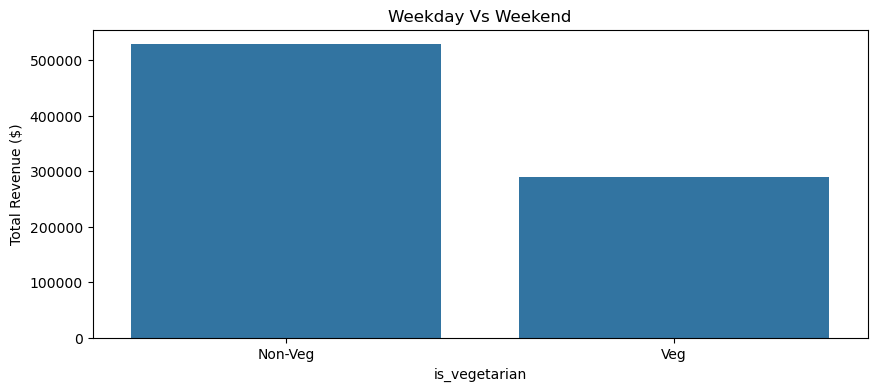

In [41]:
veg_non_veg = df.groupby('is_vegetarian')['total_price'].sum().reset_index()
plt.figure(figsize = (10,4))
sns.barplot(data = veg_non_veg,
           x = 'is_vegetarian',
           y = 'total_price')
plt.ylabel('Total Revenue ($)')
plt.title('Weekday Vs Weekend')
plt.show()

In [60]:
df.groupby('is_vegetarian')['total_price'].sum()

is_vegetarian
Non-Veg    528462.60
Veg        289397.45
Name: total_price, dtype: float64

#### `Insight`

- `Non-Veg` generates significantly more revenue — `$528,463` (`64.6%` of total)
- `Veg` contributes — `$289,397` (`35.4%` of total)
- Consistent with `Q9` — `Non-Veg` is `more popular` in both `quantity` and `revenue`
- `Non-Veg` revenue is nearly `1.8x higher` than Veg
- However, `Veg` still `contributes 35%` — a significant portion worth maintaining in the menu

#### Q19: Top 5 and Bottom 5 pizzas by revenue?

Top 5 by Revenue:
pizza_name
The Thai Chicken Pizza          43434.25
The Barbecue Chicken Pizza      42768.00
The California Chicken Pizza    41409.50
The Classic Deluxe Pizza        38180.50
The Spicy Italian Pizza         34831.25
Name: total_price, dtype: float64

Bottom 5 by Revenue:
pizza_name
The Spinach Pesto Pizza      15596.00
The Mediterranean Pizza      15360.50
The Spinach Supreme Pizza    15277.75
The Green Garden Pizza       13955.75
The Brie Carre Pizza         11588.50
Name: total_price, dtype: float64


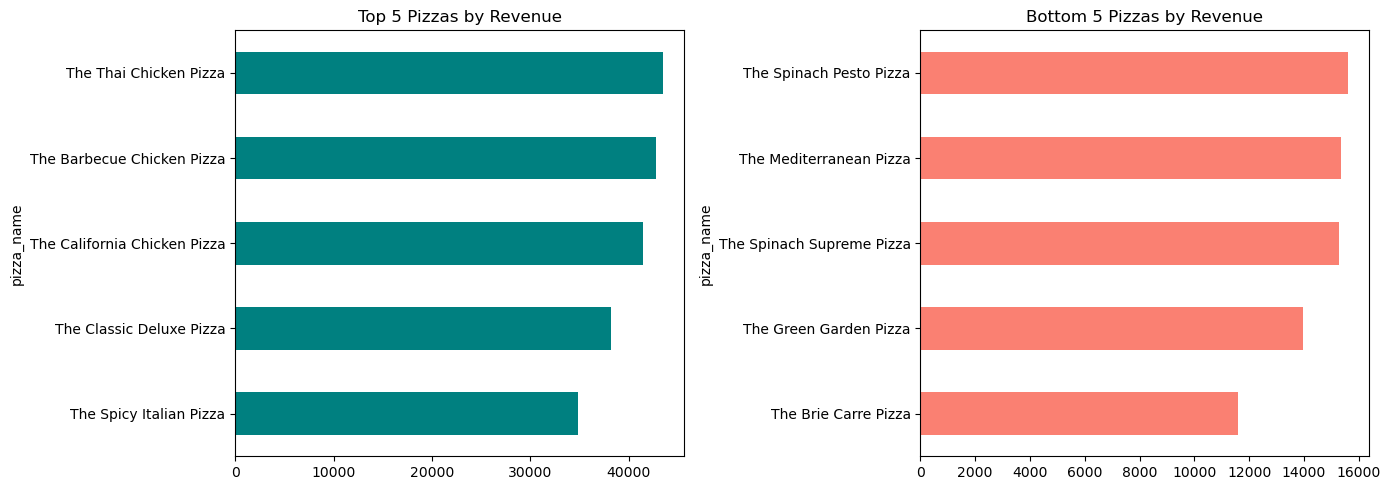

In [43]:
pizza_revenue = df.groupby('pizza_name')['total_price'].sum().sort_values(ascending=False)

# Top 5
print("Top 5 by Revenue:")
print(pizza_revenue.head())

# Bottom 5
print("\nBottom 5 by Revenue:")
print(pizza_revenue.tail())

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pizza_revenue.head().plot(kind='barh', ax=axes[0], color='teal')
axes[0].set_title('Top 5 Pizzas by Revenue')
axes[0].invert_yaxis()

pizza_revenue.tail().plot(kind='barh', ax=axes[1], color='salmon')
axes[1].set_title('Bottom 5 Pizzas by Revenue')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

#### `Insight`
##### Top 5 by Revenue:

- `Thai Chicken Pizza` is the `highest` `revenue` generator — `$43,434`
- `Barbecue Chicken` and `California Chicken` are close second and third — `~$42K and $41K`
- `3` out of top `5` are `Chicken pizzas` — `Chicken` category dominates top revenue
- `Classic Deluxe` is the only Classic in top 5 — `$38,180`

##### Bottom 5 by Revenue:

- `Brie Carre` Pizza is the worst performer — only `$11,588`
- `Green Garden` Pizza is second worst — `$13,955`
- `All bottom 5` are `Veg pizzas` — consistent with overall `Veg` vs `Non-Veg` trend
- `Bottom 5` revenue range: `$11K–$15K` vs `Top 5`: `$34K–$43K` — nearly `3x` difference

#### Q20: Top 5 and Bottom 5 pizzas by quantity sold?

Top 5 by Quantity:
pizza_name
The Classic Deluxe Pizza      2453
The Barbecue Chicken Pizza    2432
The Hawaiian Pizza            2422
The Pepperoni Pizza           2418
The Thai Chicken Pizza        2371
Name: quantity, dtype: int64

Bottom 5 by Quantity:
pizza_name
The Soppressata Pizza        961
The Spinach Supreme Pizza    950
The Calabrese Pizza          937
The Mediterranean Pizza      934
The Brie Carre Pizza         490
Name: quantity, dtype: int64


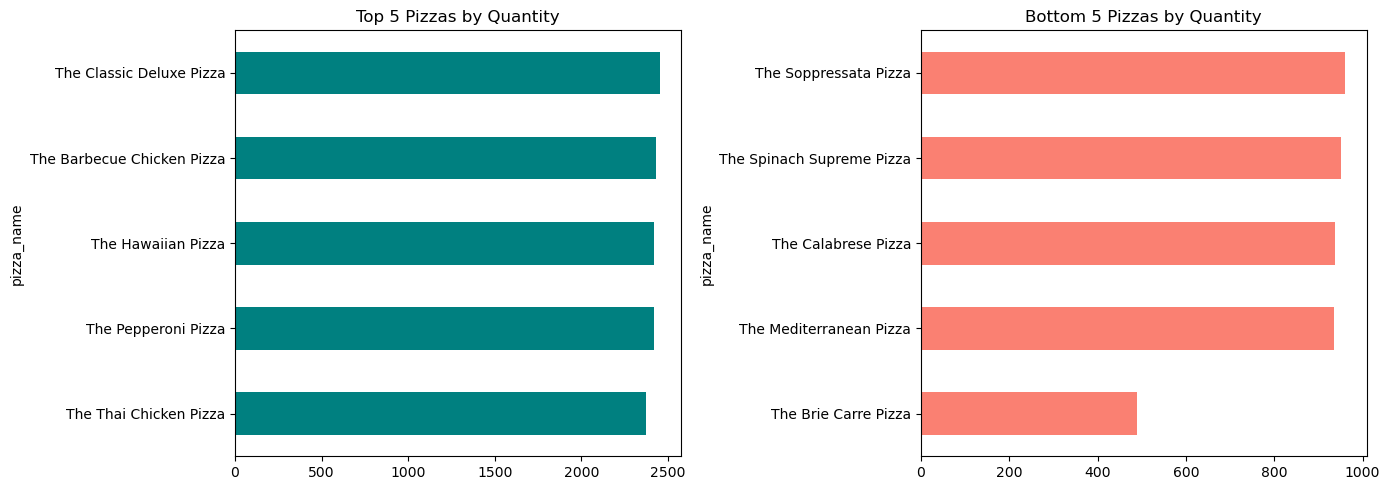

In [44]:
pizza_qty = df.groupby('pizza_name')['quantity'].sum().sort_values(ascending=False)

print("Top 5 by Quantity:")
print(pizza_qty.head())

print("\nBottom 5 by Quantity:")
print(pizza_qty.tail())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pizza_qty.head().plot(kind='barh', ax=axes[0], color='teal')
axes[0].set_title('Top 5 Pizzas by Quantity')
axes[0].invert_yaxis()

pizza_qty.tail().plot(kind='barh', ax=axes[1], color='salmon')
axes[1].set_title('Bottom 5 Pizzas by Quantity')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

#### `Insight`
##### Top 5 by Quantity:

- `Classic Deluxe Pizza` is the most sold — `2,453` units
- `Barbecue Chicken` and `Hawaiian` are close second and third — `~2,432 and 2,422`
- Top 5 are mixed categories — `Classic`, `Chicken`, and a `Veggie (Hawaiian)`
- Difference between top 5 is very small — highly competitive

##### Bottom 5 by Quantity:

- `Brie Carre Pizza` is the `worst` — only `490` units sold
- `Brie Carre` is significantly `lower` `than others` — nearly `half` of the `4th worst`
- Other `bottom 4` are close to each other — `934` to `961` units
- All `bottom 5` are `low demand` pizzas — menu `review recommended`

#### Q21: What is the correlation between `quantity`, `unit_price` and `total_price`?

             quantity  unit_price  total_price
quantity     1.000000    0.007142     0.541926
unit_price   0.007142    1.000000     0.836087
total_price  0.541926    0.836087     1.000000


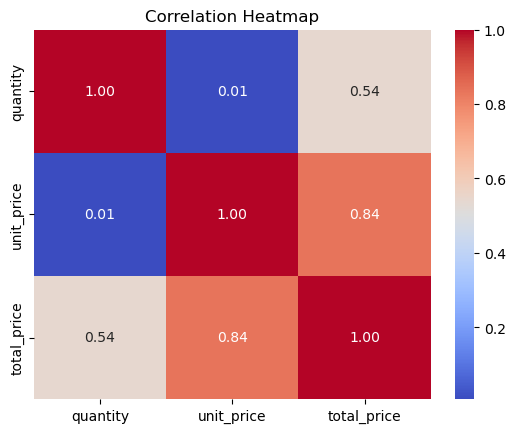

In [45]:
corr = df[['quantity', 'unit_price', 'total_price']].corr()
print(corr)

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

#### `Insight`

- `unit_price vs total_price`: `0.84` — very strong positive correlation — higher priced pizzas generate more revenue, as expected
- `quantity vs total_price`: `0.54` — moderate positive correlation — more quantity means more revenue but not as strong as price
- `quantity vs unit_price`: `0.007` — `almost zero` `correlation` — price of pizza has no relation to how many are ordered
- Key takeaway: Price drives revenue more than quantity — `premium pizzas` are the `bigger` `revenue` `contributors`



### Business Questions:

#### Q1: Which day of the week has the highest revenue, quantity and orders?

             Total_Revenue  Total_Quantity  Total_Orders
day_of_week                                             
Monday           107329.55            6485          2794
Tuesday          114133.80            6895          2973
Wednesday        114408.40            6946          3024
Thursday         123528.50            7478          3239
Friday           136073.90            8242          3538
Saturday         123182.40            7493          3158
Sunday            99203.50            6035          2624


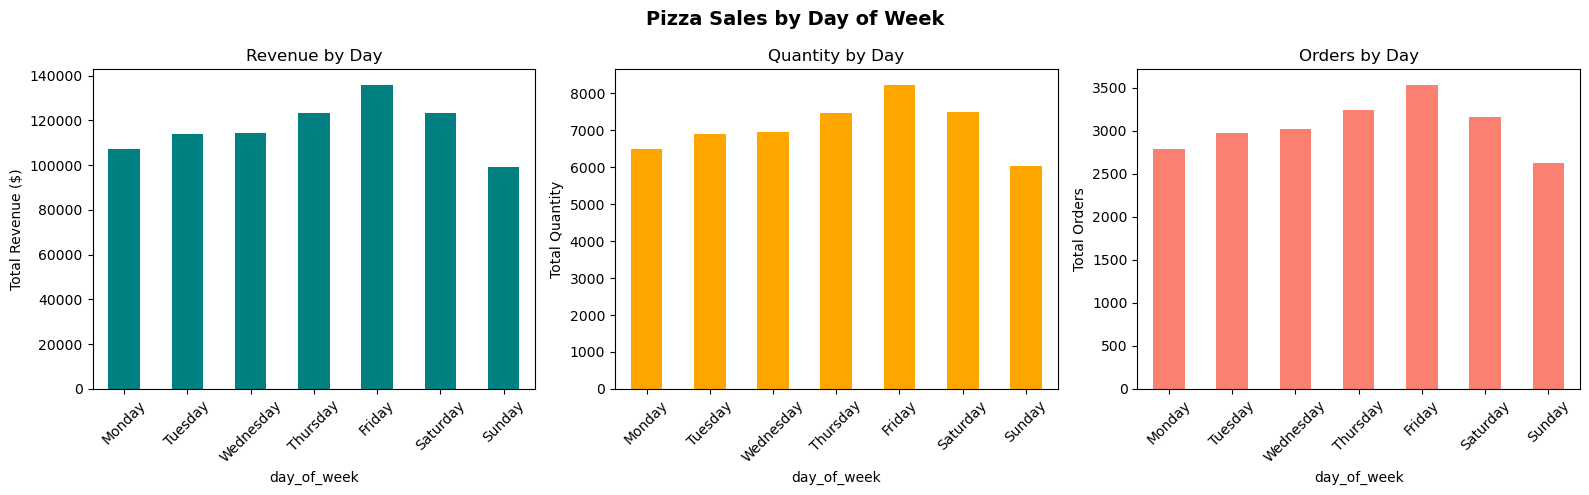

In [46]:
DAY_ORDER = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

day_analysis = df.groupby('day_of_week').agg(
    Total_Revenue=('total_price', 'sum'),
    Total_Quantity=('quantity', 'sum'),
    Total_Orders=('order_id', 'nunique')
).reindex(DAY_ORDER)

print(day_analysis)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

day_analysis['Total_Revenue'].plot(kind='bar', ax=axes[0], color='teal')
axes[0].set_title('Revenue by Day')
axes[0].set_ylabel('Total Revenue ($)')
axes[0].tick_params(axis='x', rotation=45)

day_analysis['Total_Quantity'].plot(kind='bar', ax=axes[1], color='orange')
axes[1].set_title('Quantity by Day')
axes[1].set_ylabel('Total Quantity')
axes[1].tick_params(axis='x', rotation=45)

day_analysis['Total_Orders'].plot(kind='bar', ax=axes[2], color='salmon')
axes[2].set_title('Orders by Day')
axes[2].set_ylabel('Total Orders')
axes[2].tick_params(axis='x', rotation=45)

plt.suptitle('Pizza Sales by Day of Week', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### `Insight`

- `Friday` leads in all 3 metrics — Revenue: `$136,073` | Quantity: `8,242` | Orders: `3,538`
- `Thursday` and `Saturday` are close second — both `~$123K` revenue
- `Sunday` is the `weakest day` across all metrics — Revenue: `$99,203` | Orders: `2,624`
- `Monday` is second weakest — Revenue: `$107,329`
- `Thu–Sat` = `peak days` consistently across revenue, quantity and orders
- `Sun–Mon` = `slowest days` — `promotions` or `discounts` could help boost sales

#### Q2: Which pizza category has the highest revenue, quantity and orders?

                Total_Revenue  Total_Quantity  Total_Orders
pizza_category                                             
Classic             220053.10           14888         10859
Supreme             208197.00           11987          9085
Chicken             195919.50           11050          8536
Veggie              193690.45           11649          8941


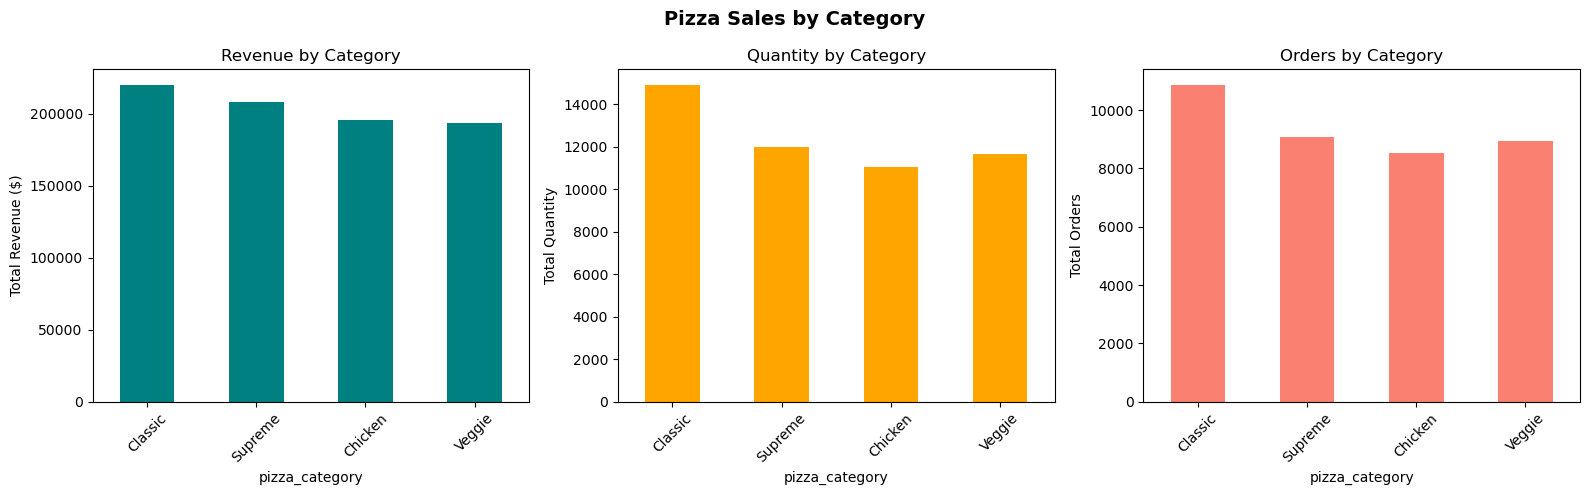

In [47]:
category_analysis = df.groupby('pizza_category').agg(
    Total_Revenue=('total_price', 'sum'),
    Total_Quantity=('quantity', 'sum'),
    Total_Orders=('order_id', 'nunique')
).sort_values('Total_Revenue', ascending=False)

print(category_analysis)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

category_analysis['Total_Revenue'].plot(kind='bar', ax=axes[0], color='teal')
axes[0].set_title('Revenue by Category')
axes[0].set_ylabel('Total Revenue ($)')
axes[0].tick_params(axis='x', rotation=45)

category_analysis['Total_Quantity'].plot(kind='bar', ax=axes[1], color='orange')
axes[1].set_title('Quantity by Category')
axes[1].set_ylabel('Total Quantity')
axes[1].tick_params(axis='x', rotation=45)

category_analysis['Total_Orders'].plot(kind='bar', ax=axes[2], color='salmon')
axes[2].set_title('Orders by Category')
axes[2].set_ylabel('Total Orders')
axes[2].tick_params(axis='x', rotation=45)

plt.suptitle('Pizza Sales by Category', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### `Insight`

- `Classic` leads in all 3 metrics — Revenue: `$220,053` | Quantity: `14,888` | Orders: `10,859`
- `Supreme` is second in revenue — `$208,197` but `quantity` is `lower` `than Veggie`
- `Veggie` sells more quantity than `Chicken` (`11,649 vs 11,050`) but `generates less revenue` — `Veggie` pizzas are `cheaper`
- `Chicken` generates more `revenue` `than Veggie` despite `lower quantity` — `Chicken pizzas` are `higher priced`
- All 4 categories are relatively balanced — no single category dominates overwhelmingly

#### Q3: Which pizza size has the highest revenue, quantity and orders?

            Total_Revenue  Total_Quantity  Total_Orders
pizza_size                                             
S               178076.50           14403         10490
M               249382.25           15635         11159
L               375318.70           18956         12736
XL               14076.00             552           544
XXL               1006.60              28            28


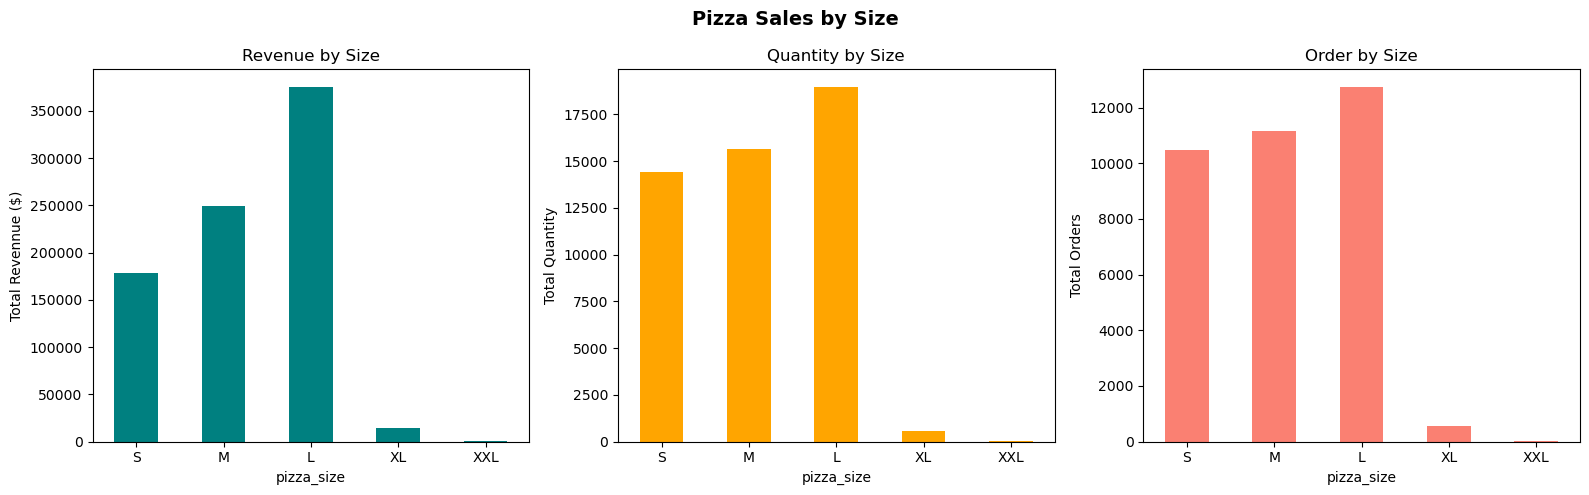

In [48]:
size_order = ['S','M','L','XL','XXL']
size_analysis = df.groupby('pizza_size').agg(
    Total_Revenue = ('total_price','sum'),
    Total_Quantity = ('quantity','sum'),
    Total_Orders = ('order_id','nunique')
 ).reindex(size_order)
print(size_analysis)

fig, axes = plt.subplots(1,3,figsize = (16,5))
size_analysis['Total_Revenue'].plot(kind = 'bar', ax = axes[0], color = 'teal')
axes[0].set_title('Revenue by Size')
axes[0].set_ylabel('Total Revennue ($)')
axes[0].tick_params(axis = 'x', rotation= 0)

size_analysis['Total_Quantity'].plot(kind = 'bar', ax = axes[1], color = 'orange')
axes[1].set_title('Quantity by Size')
axes[1].set_ylabel('Total Quantity')
axes[1].tick_params(axis = 'x', rotation= 0)

size_analysis['Total_Orders'].plot(kind = 'bar', ax = axes[2], color = 'salmon')
axes[2].set_title('Order by Size')
axes[2].set_ylabel('Total Orders')
axes[2].tick_params(axis = 'x', rotation= 0)

plt.suptitle('Pizza Sales by Size', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### `Insight`

- `Large (L)` dominates all 3 metrics — Revenue: `$375,318` | Quantity: `18,956` | Orders: `12,736`
- `Medium (M)` is consistently `second` across all metrics
- `Small (S)` is `third` — despite being `cheaper`, still generates `$178K` revenue
- `XL` and `XXL` are negligible — combined revenue only `$15,082` (`1.8%` of total)
- Clear pattern: `L > M > S >> XL >> XXL` across all metrics
- Business should `focus` on `L` and `M` sizes for `maximum` `revenue` impact

#### Q4: Which time of day has the highest revenue, quantity and orders?

             Total_Revenue  Total_Quantity  Total_Orders
time_of_day                                             
Morning           45322.45            2750          1240
Lunch            277145.00           16802          6447
Afternoon        209285.15           12666          5724
Evening          220141.15           13357          6050
Night             65966.30            3999          1889


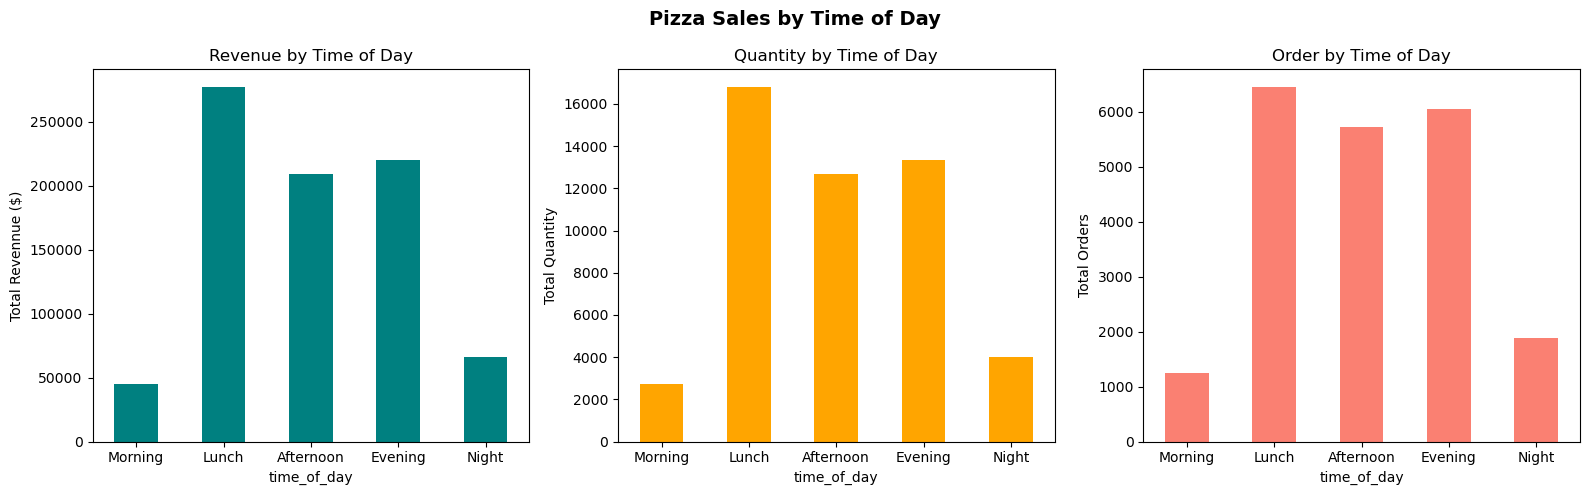

In [49]:
time_order = ['Morning', 'Lunch', 'Afternoon', 'Evening', 'Night']
time_analysis = df.groupby('time_of_day').agg(
    Total_Revenue = ('total_price','sum'),
    Total_Quantity = ('quantity','sum'),
    Total_Orders = ('order_id','nunique')
 ).reindex(time_order)
print(time_analysis)


fig, axes = plt.subplots(1,3,figsize = (16,5))
time_analysis['Total_Revenue'].plot(kind = 'bar', ax = axes[0], color = 'teal')
axes[0].set_title('Revenue by Time of Day')
axes[0].set_ylabel('Total Revennue ($)')
axes[0].tick_params(axis = 'x', rotation= 0)

time_analysis['Total_Quantity'].plot(kind = 'bar', ax = axes[1], color = 'orange')
axes[1].set_title('Quantity by Time of Day')
axes[1].set_ylabel('Total Quantity')
axes[1].tick_params(axis = 'x', rotation= 0)

time_analysis['Total_Orders'].plot(kind = 'bar', ax = axes[2], color = 'salmon')
axes[2].set_title('Order by Time of Day')
axes[2].set_ylabel('Total Orders')
axes[2].tick_params(axis = 'x', rotation= 0)

plt.suptitle('Pizza Sales by Time of Day', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### `Insight`
- `Lunch` dominates all 3 metrics — Revenue: `$277,145` | Quantity: `16,802` | Orders: `6,447`
- `Evening` is second — Revenue: `$220,141` | Orders: `6,050`
- `Afternoon` is third — Revenue: `$209,285`
- `Morning` is the weakest — Revenue: `$45,322` | Orders: only `1,240`
- `Lunch + Evening` combined = `~$497K` — over `60%` of total revenue
- `Morning` and `Night` together = only `$111K` — just `13.5%` of total
- `Staff` and `promotions` should be heavily focused on `Lunch` and `Evening` hours

#### Q5: What is the revenue, quantity and orders comparison between Weekday and Weekend?

            Total_Revenue  Total_Quantity  Total_Orders
is_weekend                                             
Weekday         595474.15           36046         15568
Weekend         222385.90           13528          5782


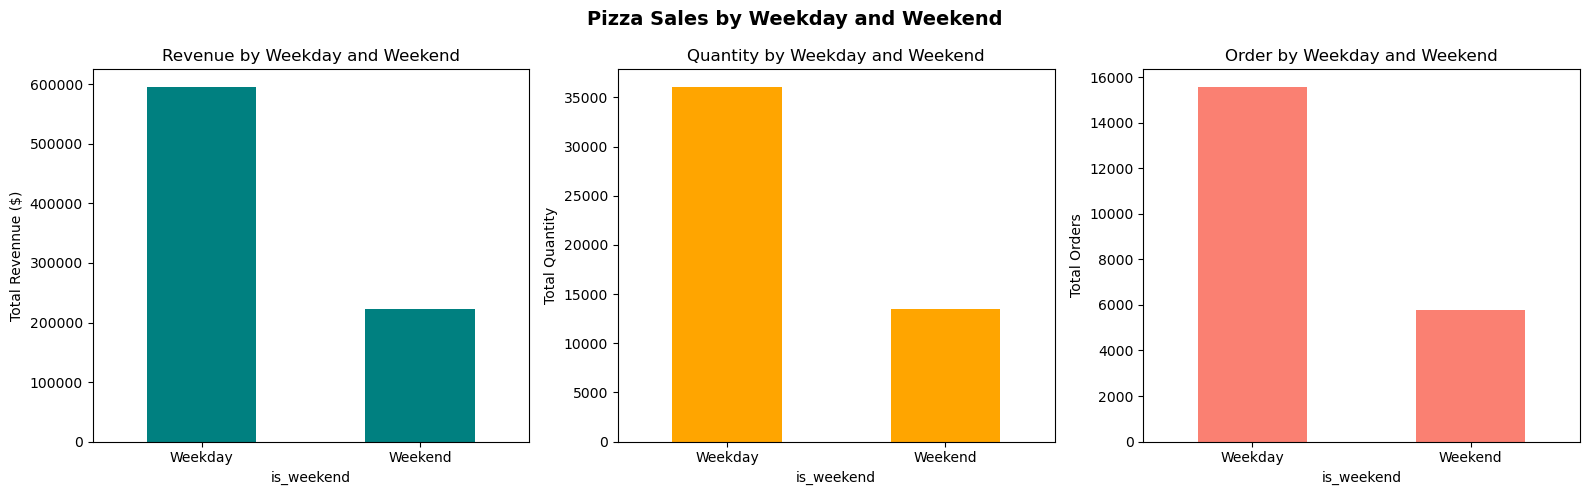

In [50]:
weekend_analysis = df.groupby('is_weekend').agg(
    Total_Revenue = ('total_price','sum'),
    Total_Quantity = ('quantity','sum'),
    Total_Orders = ('order_id','nunique')
 )
print(weekend_analysis)


fig, axes = plt.subplots(1,3,figsize = (16,5))
weekend_analysis['Total_Revenue'].plot(kind = 'bar', ax = axes[0], color = 'teal')
axes[0].set_title('Revenue by Weekday and Weekend')
axes[0].set_ylabel('Total Revennue ($)')
axes[0].tick_params(axis = 'x', rotation= 0)

weekend_analysis['Total_Quantity'].plot(kind = 'bar', ax = axes[1], color = 'orange')
axes[1].set_title('Quantity by Weekday and Weekend')
axes[1].set_ylabel('Total Quantity')
axes[1].tick_params(axis = 'x', rotation= 0)

weekend_analysis['Total_Orders'].plot(kind = 'bar', ax = axes[2], color = 'salmon')
axes[2].set_title('Order by Weekday and Weekend')
axes[2].set_ylabel('Total Orders')
axes[2].tick_params(axis = 'x', rotation= 0)

plt.suptitle('Pizza Sales by Weekday and Weekend', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### Insight:

- Weekday dominates all 3 metrics — Revenue: `$595,474` | Quantity: `36,046` | Orders: `15,568`
- Weekend contributes — Revenue: `$222,386` | Quantity: `13,528` | Orders: `5,782`
- But per day average:
    - `Weekday`: `$595,474 ÷ 5` = `$119,095`/day
    - `Weekend`: `$222,386 ÷ 2` = `$111,193`/day
- Per day difference is only `~7%` — demand is fairly consistent daily
- Weekday dominates in totals simply because there are more weekdays

#### Q6: What is the revenue, quantity and orders comparison between Veg and Non-Veg?

               Total_Revenue  Total_Quantity  Total_Orders
is_vegetarian                                             
Non-Veg            528462.60           32616         17655
Veg                289397.45           16958         11766


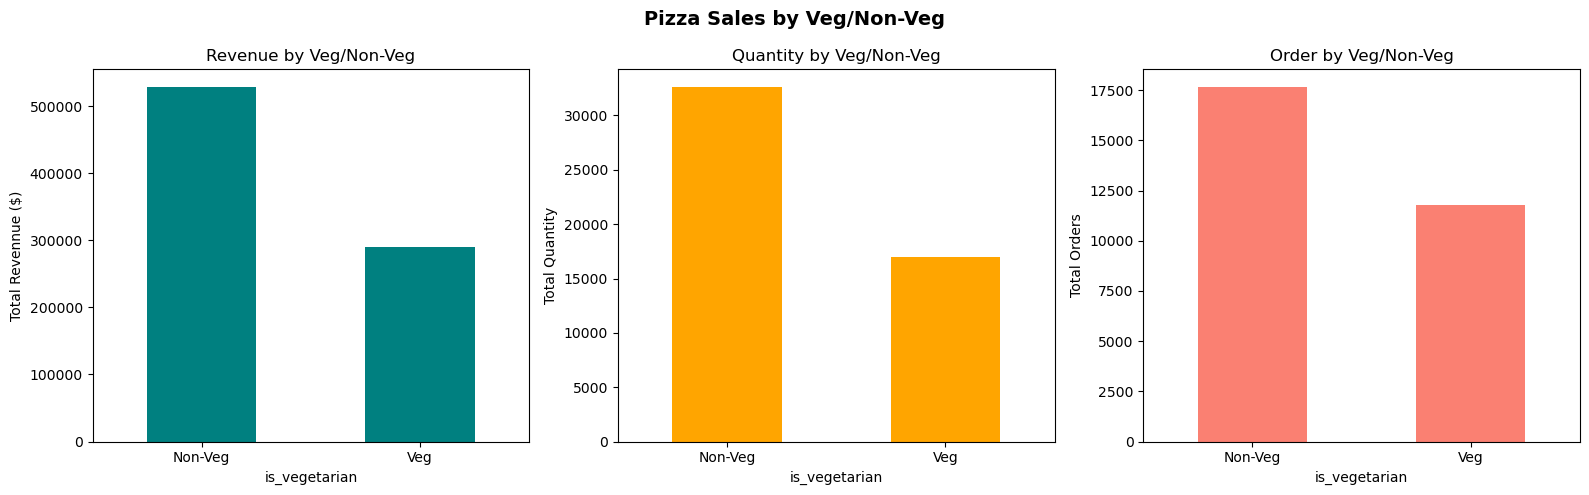

In [51]:
vegeterian_analysis = df.groupby('is_vegetarian').agg(
    Total_Revenue = ('total_price','sum'),
    Total_Quantity = ('quantity','sum'),
    Total_Orders = ('order_id','nunique')
 )
print(vegeterian_analysis)


fig, axes = plt.subplots(1,3,figsize = (16,5))
vegeterian_analysis['Total_Revenue'].plot(kind = 'bar', ax = axes[0], color = 'teal')
axes[0].set_title('Revenue by Veg/Non-Veg')
axes[0].set_ylabel('Total Revennue ($)')
axes[0].tick_params(axis = 'x', rotation= 0)

vegeterian_analysis['Total_Quantity'].plot(kind = 'bar', ax = axes[1], color = 'orange')
axes[1].set_title('Quantity by Veg/Non-Veg')
axes[1].set_ylabel('Total Quantity')
axes[1].tick_params(axis = 'x', rotation= 0)

vegeterian_analysis['Total_Orders'].plot(kind = 'bar', ax = axes[2], color = 'salmon')
axes[2].set_title('Order by Veg/Non-Veg')
axes[2].set_ylabel('Total Orders')
axes[2].tick_params(axis = 'x', rotation= 0)

plt.suptitle('Pizza Sales by Veg/Non-Veg', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### `Insight`

- `Non-Veg` dominates all 3 metrics — Revenue: `$528,463` | Quantity: `32,616` | Orders: `17,655`
- `Veg` contributes — Revenue: `$289,397` | Quantity: `16,958` | Orders: `11,766`
- `Non-Veg` revenue is `1.8x` higher than Veg
- `Non-Veg` accounts for `64.6%` of total revenue
- `Veg` still contributes `35.4%` — a significant portion worth maintaining
- Menu should prioritize `Non-Veg` but not neglect `Veg` options



#### Q7: What is the monthly revenue, quantity and orders trend?

            Total_Revenue  Total_Quantity  Total_Orders
month_name                                             
Apr              68736.80            4151          1799
Aug              68278.25            4168          1841
Dec              64701.15            3935          1680
Feb              65159.60            3961          1685
Jan              69793.30            4232          1845
Jul              72557.90            4392          1935
Jun              68230.20            4107          1773
Mar              70397.10            4261          1840
May              71402.75            4328          1853
Nov              70395.35            4266          1792
Oct              64027.60            3883          1646
Sep              64180.05            3890          1661


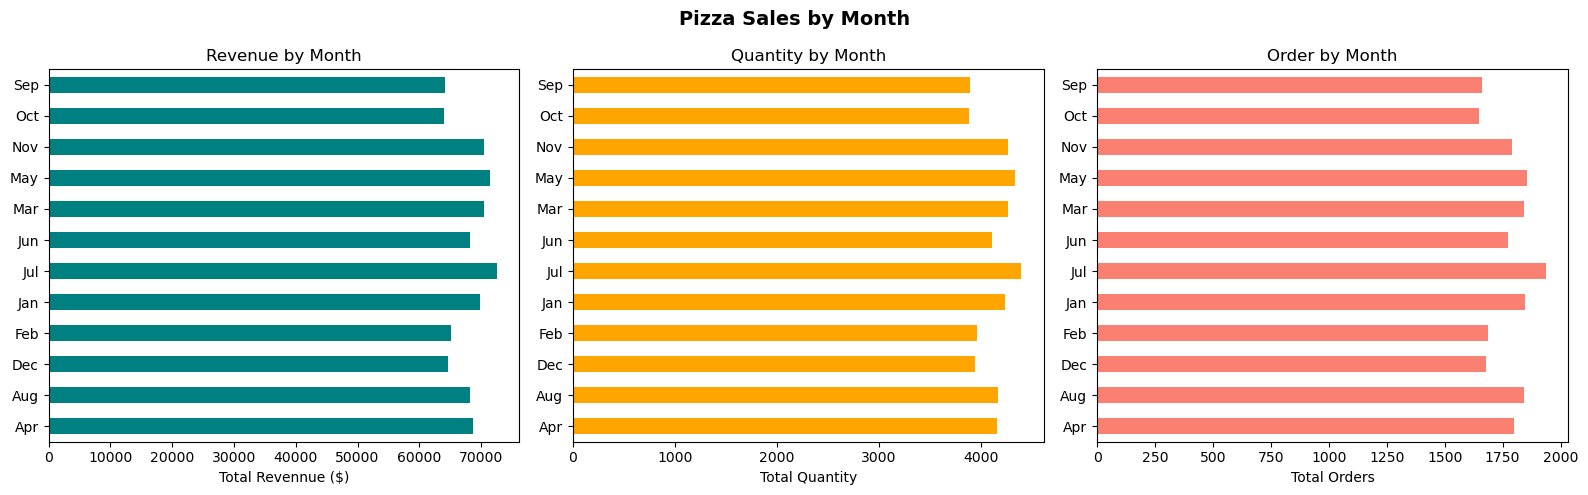

In [63]:
monthly_analysis = df.groupby('month_name').agg(
    Total_Revenue = ('total_price','sum'),
    Total_Quantity = ('quantity','sum'),
    Total_Orders = ('order_id','nunique')
 )
print(monthly_analysis)


fig, axes = plt.subplots(1,3,figsize = (16,5))
monthly_analysis['Total_Revenue'].plot(kind = 'barh', ax = axes[0], color = 'teal')
axes[0].set_title('Revenue by Month')
axes[0].set_xlabel('Total Revennue ($)')
axes[0].set_ylabel('')
axes[0].tick_params(axis = 'x', rotation= 0)

monthly_analysis['Total_Quantity'].plot(kind = 'barh', ax = axes[1], color = 'orange')
axes[1].set_title('Quantity by Month')
axes[1].set_xlabel('Total Quantity')
axes[1].set_ylabel('')
axes[1].tick_params(axis = 'x', rotation= 0)

monthly_analysis['Total_Orders'].plot(kind = 'barh', ax = axes[2], color = 'salmon')
axes[2].set_title('Order by Month')
axes[2].set_xlabel('Total Orders')
axes[2].set_ylabel('')
axes[2].tick_params(axis = 'x', rotation= 0)

plt.suptitle('Pizza Sales by Month', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### `Insight`

- `July` is the best month across all metrics — Revenue: `$72,557` | Quantity: `4,392` | Orders: `1,935`
- `May` and March are close second — `~$70K–$71K` revenue
- `October` is the weakest month — Revenue: `$64,027` | Orders: `1,646`
- `December` and `February` are also low — `~$64K–$65K`
- Overall monthly trend is very consistent — range is only `$64K–$72K`
- `Summer months` (`May–July`) perform slightly `better`
- `Q4` months (`Oct, Nov, Dec`) show slight `decline` — possible seasonal dip

#### Q8: What is the quarterly revenue, quantity and orders trend?

         Total_Revenue  Total_Quantity  Total_Orders
quarter                                             
Q1           205350.00           12454          5370
Q2           208369.75           12586          5425
Q3           205016.20           12450          5437
Q4           199124.10           12084          5118


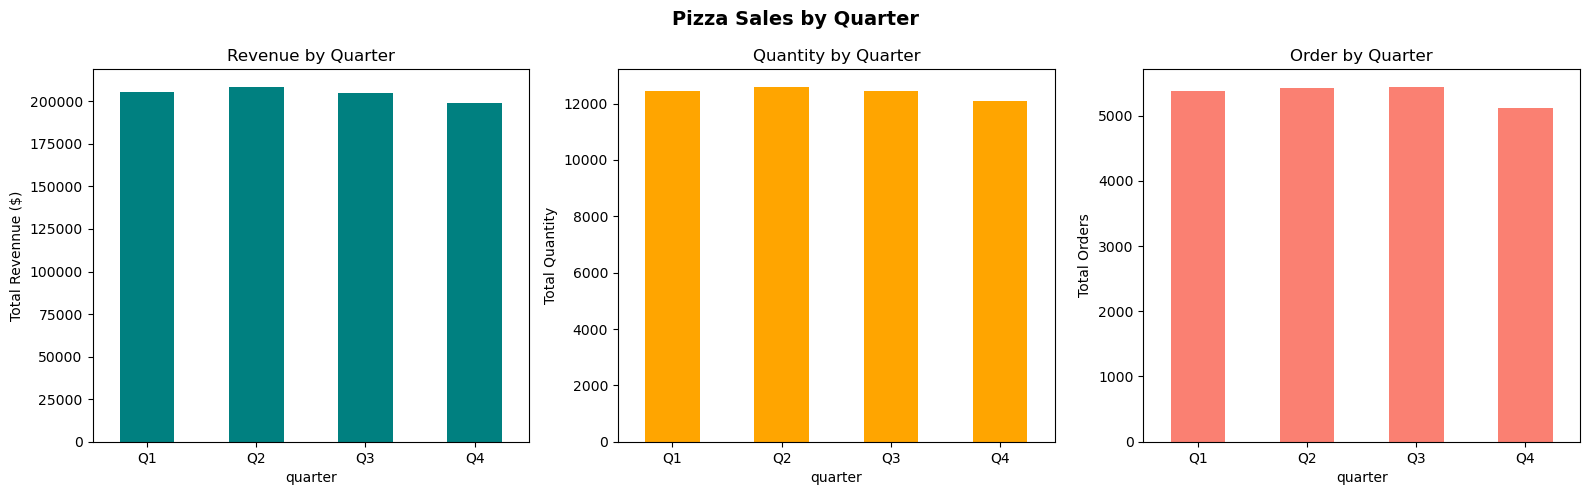

In [53]:
quarterly_analysis = df.groupby('quarter').agg(
    Total_Revenue = ('total_price','sum'),
    Total_Quantity = ('quantity','sum'),
    Total_Orders = ('order_id','nunique')
 )
print(quarterly_analysis)


fig, axes = plt.subplots(1,3,figsize = (16,5))
quarterly_analysis['Total_Revenue'].plot(kind = 'bar', ax = axes[0], color = 'teal')
axes[0].set_title('Revenue by Quarter')
axes[0].set_ylabel('Total Revennue ($)')
axes[0].tick_params(axis = 'x', rotation= 0)

quarterly_analysis['Total_Quantity'].plot(kind = 'bar', ax = axes[1], color = 'orange')
axes[1].set_title('Quantity by Quarter')
axes[1].set_ylabel('Total Quantity')
axes[1].tick_params(axis = 'x', rotation= 0)

quarterly_analysis['Total_Orders'].plot(kind = 'bar', ax = axes[2], color = 'salmon')
axes[2].set_title('Order by Quarter')
axes[2].set_ylabel('Total Orders')
axes[2].tick_params(axis = 'x', rotation= 0)

plt.suptitle('Pizza Sales by Quarter', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### `Insight`

- `Q2` is the best quarter across all metrics — Revenue: `$208,369` | Quantity: `12,586` | Orders: `5,425`
- `Q1` and `Q3` are very close — Revenue `~$205K`, Quantity `~12,450`
- `Q4` is the weakest quarter — Revenue: `$199,124` | Quantity: `12,084` | Orders: `5,118`
- Difference between `best` `(Q2)` and `worst` `(Q4)` is only `~$9,245` — `very stable`
- Orders in `Q3` slightly higher than `Q1` despite lower revenue — `Q3` has slightly cheaper orders
- Business maintains consistent performance year-round with a slight `Q4` dip

#### Q9: Top 5 and Bottom 5 pizzas by revenue, quantity and orders?

Top 5 Pizzas                               Total_Revenue  Total_Quantity  Total_Orders
pizza_name                                                               
The Thai Chicken Pizza             43434.25            2371          2225
The Barbecue Chicken Pizza         42768.00            2432          2273
The California Chicken Pizza       41409.50            2370          2197
The Classic Deluxe Pizza           38180.50            2453          2329
The Spicy Italian Pizza            34831.25            1924          1822
Bottom 5 Pizzas                            Total_Revenue  Total_Quantity  Total_Orders
pizza_name                                                            
The Spinach Pesto Pizza         15596.00             970           945
The Mediterranean Pizza         15360.50             934           912
The Spinach Supreme Pizza       15277.75             950           918
The Green Garden Pizza          13955.75             997           976
The Brie Carre Pizza       

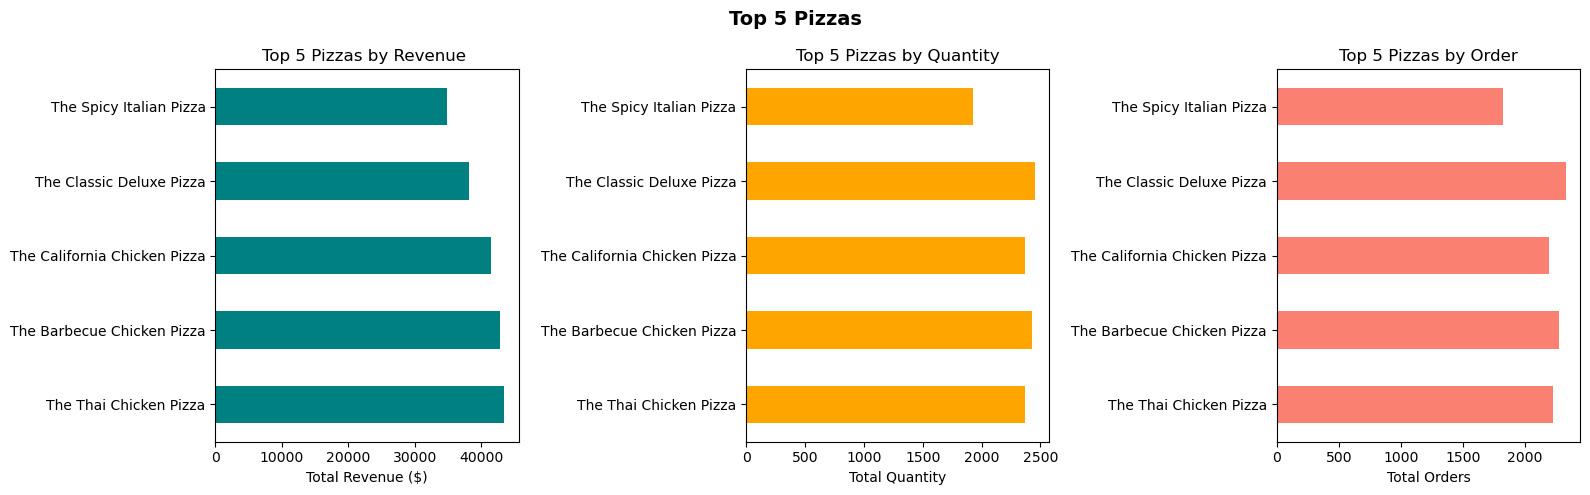

In [54]:
best_pizza_analysis = df.groupby('pizza_name').agg(
    Total_Revenue = ('total_price','sum'),
    Total_Quantity = ('quantity','sum'),
    Total_Orders = ('order_id','nunique')
 ).sort_values('Total_Revenue', ascending=False)
print('Top 5 Pizzas',best_pizza_analysis.head())
print('Bottom 5 Pizzas',best_pizza_analysis.tail())

fig, axes = plt.subplots(1,3,figsize = (16,5))
best_pizza_analysis.head()['Total_Revenue'].plot(kind = 'barh', ax = axes[0], color = 'teal')
axes[0].set_title('Top 5 Pizzas by Revenue ')
axes[0].set_xlabel('Total Revenue ($)')
axes[0].set_ylabel('')
axes[0].tick_params(axis = 'x', rotation= 0)

best_pizza_analysis.head()['Total_Quantity'].plot(kind = 'barh', ax = axes[1], color = 'orange')
axes[1].set_title('Top 5 Pizzas by Quantity')
axes[1].set_xlabel('Total Quantity')
axes[1].set_ylabel('')
axes[1].tick_params(axis = 'x', rotation= 0)

best_pizza_analysis.head()['Total_Orders'].plot(kind = 'barh', ax = axes[2], color = 'salmon')
axes[2].set_title('Top 5 Pizzas by Order')
axes[2].set_xlabel('Total Orders')
axes[2].set_ylabel('')
axes[2].tick_params(axis = 'x', rotation= 0)

plt.suptitle('Top 5 Pizzas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

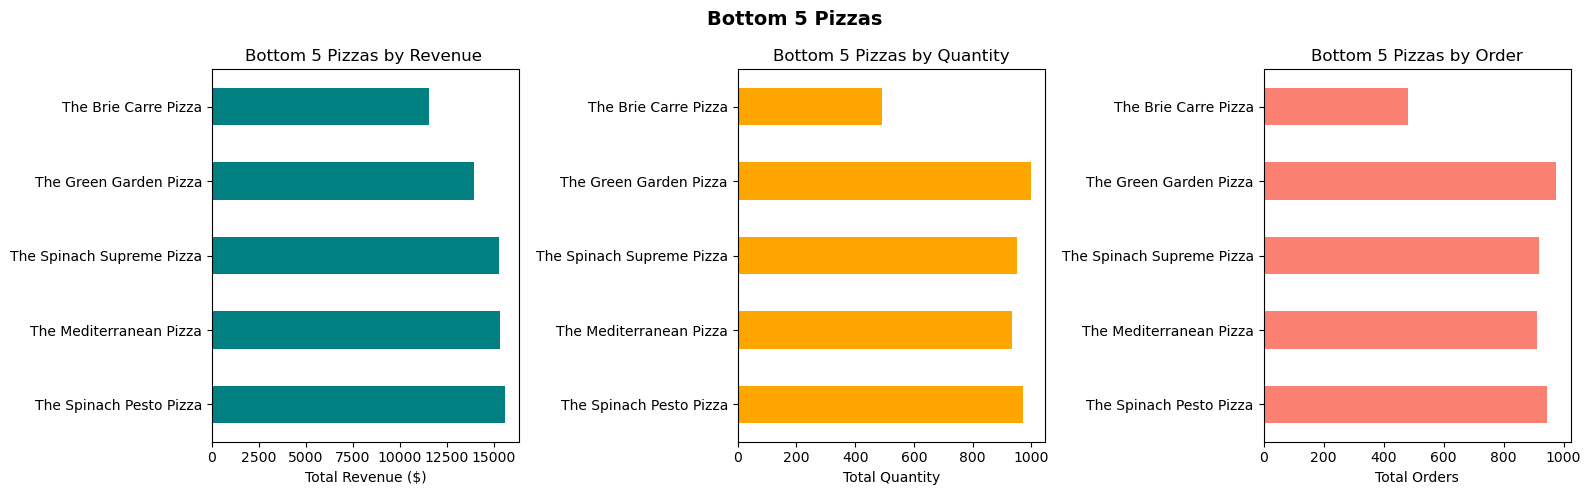

In [55]:
# Bottom 5
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
best_pizza_analysis.tail()['Total_Revenue'].plot(kind = 'barh', ax = axes[0], color = 'teal')
axes[0].set_title('Bottom 5 Pizzas by Revenue ')
axes[0].set_xlabel('Total Revenue ($)')
axes[0].set_ylabel('')
axes[0].tick_params(axis = 'x', rotation= 0)

best_pizza_analysis.tail()['Total_Quantity'].plot(kind = 'barh', ax = axes[1], color = 'orange')
axes[1].set_title('Bottom 5 Pizzas by Quantity')
axes[1].set_xlabel('Total Quantity')
axes[1].set_ylabel('')
axes[1].tick_params(axis = 'x', rotation= 0)

best_pizza_analysis.tail()['Total_Orders'].plot(kind = 'barh', ax = axes[2], color = 'salmon')
axes[2].set_title('Bottom 5 Pizzas by Order')
axes[2].set_xlabel('Total Orders')
axes[2].set_ylabel('')
axes[2].tick_params(axis = 'x', rotation= 0)

plt.suptitle('Bottom 5 Pizzas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### `Insight`
##### Top 5 Pizzas:

- `Thai Chicken Pizza` leads in revenue — `$43,434` despite not being `#1` in quantity
- `Classic Deluxe` has the highest quantity `(2,453)` and orders `(2,329)` but only `4th` in revenue — it's a lower priced pizza
- Top 3 are all Chicken pizzas — Chicken category dominates revenue
- `Spicy Italian` is 5th in revenue but only `1,924` in quantity — it's a higher priced pizza

##### Bottom 5 Pizzas:

- `Brie Carre Pizza` is the worst across all 3 metrics — Revenue: `$11,588` | Quantity: `490` | Orders: `480`
- `Brie Carre` is significantly worse than others — nearly half the quantity of other bottom pizzas
- `Green Garden` has highest quantity (`997`) among bottom 5 but lowest revenue after `Brie Carre` — very cheap pizza
- All bottom 5 are `Veg pizzas` — consistent with overall `Veg` underperformance

In [56]:
df['order_id'].nunique()

21350